# Standard meta-population model
A lot of this work will compare things against a standard meta-population model. Here it is implemented.

Data is then simulated from the model, and fitted to the model to verify the inference method recovers valid parameters when the underlying data behaves exactly as the model predicts.

This is stage (a) of "Escaping the Rat Race".

## Notebook setup

In [52]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
from grab_data import get_matrix, get_population_sizes
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.optimize as optimize
from copy import deepcopy
from itertools import product

# Model

### Transition rates
$S \rightarrow I$: $\lambda^{SI}_i(t) = \frac{\beta}{N_i}[\psi I_i(t) + (1-\psi)\sum_{j\ne i} C_{ji} \frac{I_j}{N_j}]$


$I \rightarrow R$: $\lambda^{IR}_i(t) = \gamma$

### Chain binomial
New infections in patch $i$ in $(t, t+\Delta]$:

$\delta_i^{SI}(t) \sim \text{Binomial}(S_i(t), 1-\exp(-\Delta \cdot \lambda^{SI}_i(t)))$

New recoveries in patch $i$ in $(t, t+\Delta]$:

$\delta_i^{IR}(t) \sim \text{Binomial}(I_i(t), 1-\exp(-\Delta \cdot \lambda^{IR}_i(t)))$

### State updates
$S_i(t+\Delta) = S_i(t) - \delta_i^{SI}$

$I_i(t+\Delta) = I_i(t) + \delta_i^{SI} - \delta_i^{IR}$

$R_i(t+\Delta) = R_i(t) + \delta_i^{IR}$




In [54]:
def make_foi_fn(flow_matrix, population_sizes, bulk=False):
    # so we can sum over entire matrix without having to account for j=i.
    np.fill_diagonal(flow_matrix, 0)

    def foi_fn(infections, beta, psi):
        between = (1 - psi) * np.dot(flow_matrix.T, infections / population_sizes)
        within = psi * infections
        return beta / population_sizes * (between + within)

    def bulk_foi_fn(infections, beta, psi):
        # Repeat data to allow bulk operations across time axis as well as patch axis
        t_max = infections.shape[0]
        population_sizes_bulk = np.repeat(population_sizes[None, ...], t_max, axis=0)
        flow_matrix_bulk = np.repeat(flow_matrix.T[None, ...], t_max, axis=0)

        between = (1 - psi) * np.einsum('ijk,ik->ij', flow_matrix_bulk, infections / population_sizes_bulk)
        within = psi * infections

        return beta / population_sizes_bulk * (within + between)

    if bulk:
        return bulk_foi_fn
    return foi_fn

In [55]:
def simulate(beta, gamma, psi, flow_matrix, population_sizes, seed_patch, t_max=100, t_delta=1):
    # state and initial conditions
    n = len(population_sizes)
    time_size = int(t_max // t_delta)
    s, i, r = (np.zeros(shape=(time_size, n), dtype=int),
               np.zeros(shape=(time_size, n), dtype=int),
               np.zeros(shape=(time_size, n), dtype=int))

    s[0, :] = population_sizes
    s[0, seed_patch] -= 1
    i[0, seed_patch] += 1
    # simulation
    foi = make_foi_fn(flow_matrix, population_sizes)
    rng = np.random.default_rng()
    for t in range(time_size - 1):
        delta_infections = rng.binomial(s[t, :], 1 - np.exp(-t_delta * foi(i[t, :], beta, psi)))
        delta_recoveries = rng.binomial(i[t, :], 1 - np.exp(-t_delta * gamma))

        s[t + 1, :] = s[t, :] - delta_infections
        i[t + 1, :] = i[t, :] + delta_infections - delta_recoveries
        r[t + 1, :] = r[t, :] + delta_recoveries
    return s, i, r

# Log likelihood
I ignore constants, let $S_{it}, I_{it}, R_{it}$ be observations of each state in patch $i$ at time $t$.
We can then write observed versions of the deltas in the model:

$$\hat{\delta}^{SI}_{it} = S_{it} - S_{i(t+\Delta)}$$

$$\hat{\delta}^{IR}_{it} = R_{i(t+\Delta)} - R_{it}$$

Since we have a binomial data generating mechanism for both of these deltas, and plugging in data to the force of infection we get the negative log likelihood:
$$Q(\beta, \gamma, \psi) = \sum_{i,t} -\hat\delta^{IR}_{it}\log(1-e^{-\Delta\cdot\gamma}) + \Delta\cdot\gamma (I_{it} - \hat \delta^{IR}_{it}) - \hat\delta^{SI}_{it}\log(1-e^{-\Delta\cdot\lambda_i(t)}) + \Delta\cdot\lambda_i(t) (I_{it} - \hat \delta^{SI}_{it})$$
we can then maximise this function over our parameters to estimate them.

To avoid optimising over a 3D surface, we split up the likelihood to the $\beta, \psi$ terms and the $\gamma$ terms and optimise separately.





In [183]:
def gamma_nll(gamma, state, t_delta=1):
    """"
    Negative log-likelihood function for gamma.
    """
    _, i, r = state
    deltas = np.diff(r, axis=0)
    ll_entries = np.log(1 - np.exp(-t_delta * gamma)) * deltas - t_delta * gamma * (i[:-1, :] - deltas)
    return -1 * ll_entries.sum(axis=(0, 1))

In [184]:
def transmission_nll(params, state, population_sizes, flow_matrix, t_delta=1):
    """
    Negative log-likelihood function for beta and psi.
    """
    beta, psi = params
    s, i, r = state
    # shifted_s = np.concatenate([s[1:, :], np.zeros(shape=(1, n))], axis=0)
    deltas = -1*np.diff(s, axis=0)

    foi_fn = make_foi_fn(flow_matrix, population_sizes, bulk=True)
    foi = foi_fn(i, beta, psi)
    sane_foi = deepcopy(foi)
    sane_foi[foi == 0] = 0
    sane_foi[foi != 0] = np.exp(-t_delta * sane_foi[foi != 0])
    ll_entries = deltas * np.log(1 - sane_foi[:-1,:]) - t_delta * foi[:-1,:] * (s[:-1,:] - deltas)
    return -1*ll_entries.sum(axis=(0, 1))

# Simulate using 2011 Census

In [122]:
sim_state = simulate(beta=1.8, gamma=0.3, psi=0.8, flow_matrix=get_matrix(),
                     population_sizes=get_population_sizes(), seed_patch=0, t_delta=0.5)

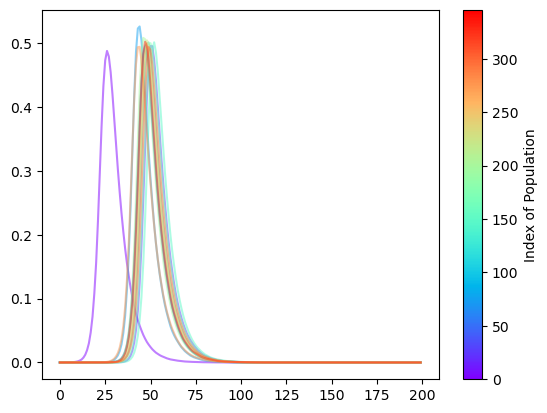

In [142]:
pop_sizes = get_population_sizes()
norm = plt.Normalize(0, pop_sizes.size)
cmap = plt.get_cmap('rainbow')
fig, ax = plt.subplots()

for i in range(0, pop_sizes.size, 25):
    ax.plot(np.arange(sim_state[1].shape[0]), sim_state[1][:, i] / pop_sizes[i], color=cmap(norm(i)), alpha=0.5)
# Add colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for colorbar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Index of Population")
plt.show()

# Fit model to simulated data

In [141]:
def fit_model(data, flow_matrix, population_sizes, t_delta=1):
    """
    Given tuple of (S,I,R) which each have shape (time, patch),
    estimate beta, gamma, psi using numerical optimisation of maximum likelihood.
    :param t_delta:
    :param data:
    :param flow_matrix:
    :param population_sizes:
    :return:
    """
    gamma = optimize.minimize(gamma_nll,
                              np.array([0.5]),
                              args=(data, t_delta),
                              method='L-BFGS-B',
                              bounds=[(0.001, 2)]).x[0]
    beta, psi = optimize.minimize(transmission_nll,
                                  np.array([1.8, 0.8]),
                                  args=(data, population_sizes, flow_matrix, t_delta),
                                  method='L-BFGS-B',
                                  bounds=[(0.01, 10), (0.001, 0.9)]).x
    return beta, gamma, psi


In [169]:
def simulate_and_fit(flow_matrix, population_sizes, seed_patch, t_max=100, t_delta=1):
    true_params = list(product(np.linspace(1, 3, 10), np.linspace(0.2, 0.8, 10), np.array([0.9, 0.8,0.7])))
    results = [[], [], []]
    for b, g, p in true_params:
        if b / g <= 1:
            continue
        sim_data = simulate(beta=b, gamma=g,
                            psi=p, flow_matrix=flow_matrix,
                            population_sizes=population_sizes,
                            seed_patch=seed_patch, t_max=t_max, t_delta=t_delta)
        # not interested in extinctions
        while sim_data[1].sum(axis=(0, 1)) <= 100:
            sim_data = simulate(beta=b, gamma=g,
                                psi=p, flow_matrix=flow_matrix,
                                population_sizes=population_sizes,
                                seed_patch=seed_patch, t_max=t_max, t_delta=t_delta)
        b_hat, g_hat, psi_hat = fit_model(sim_data, flow_matrix, population_sizes, t_delta=t_delta)
        results[0].append(b_hat)
        results[1].append(g_hat)
        results[2].append(psi_hat)

    return np.array(true_params), np.array(results).T

In [174]:
census_flow = get_matrix()
census_population = get_population_sizes()
true_vals, estimated_vals = simulate_and_fit(flow_matrix=census_flow, population_sizes=census_population, seed_patch=0,
                                             t_max=250, t_delta=0.5)

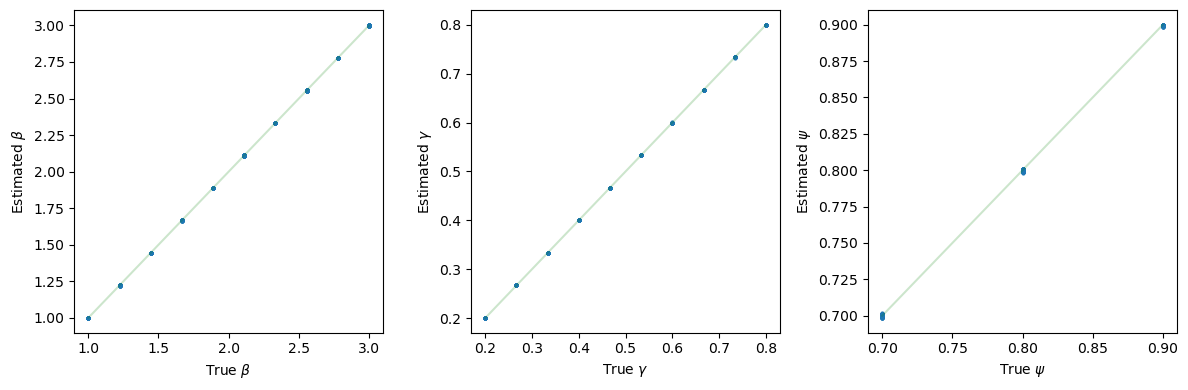

In [182]:
fig, ax = plt.subplots(nrows=1, ncols=3)
fig.set_size_inches(12, 4)
param_names = [r'$\beta$', r'$\gamma$', r'$\psi$']
norm = plt.Normalize(true_vals[:, 0].min(), true_vals[:, 0].max())
cmap = plt.get_cmap('rainbow')
for index, param in enumerate(param_names):
    ax[index].scatter(true_vals[:, index], estimated_vals[:, index], s=4)
    ax[index].plot(true_vals[:, index], true_vals[:, index], c='g', alpha=0.2)
    ax[index].set_xlabel(f'True {param}')
    ax[index].set_ylabel(f'Estimated {param}')

fig.tight_layout()
plt.show()

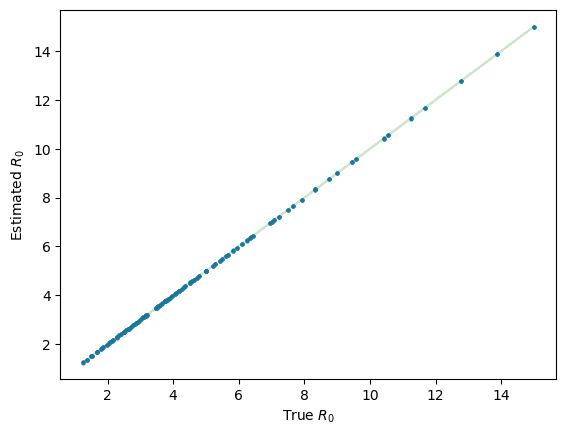

In [176]:
plt.scatter(true_vals[:, 0] / true_vals[:, 1], estimated_vals[:, 0] / estimated_vals[:, 1], s=4)
plt.plot(true_vals[:, 0] / true_vals[:, 1], true_vals[:, 0] / true_vals[:, 1], c='g', alpha=0.2)
plt.xlabel(r'True $R_0$')
plt.ylabel(f'Estimated $R_0$')
plt.show()